<a href="https://colab.research.google.com/github/saifmukadam10/Q-Learning-on-a-Grid-World/blob/main/Q_Learning_on_a_Grid_World.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# 1. ROBUST ENVIRONMENT
# ==========================================
class GridWorld:
    def __init__(self):
        self.rows = 4
        self.cols = 4
        self.start = (0, 0)
        self.goal = (3, 3)
        self.obstacles = [(1, 1), (1, 3), (2, 3), (3, 0)]
        self.terminals = [self.goal] + self.obstacles

    def step(self, state, action):
        # Action: 0:Up, 1:Right, 2:Down, 3:Left
        r, c = state
        if state in self.terminals:
            return state, 0, True # Stuck in terminal state

        if action == 0:   nr, nc = max(r - 1, 0), c
        elif action == 1: nr, nc = r, min(c + 1, self.cols - 1)
        elif action == 2: nr, nc = min(r + 1, self.rows - 1), c
        elif action == 3: nr, nc = r, max(c - 1, 0)
        next_state = (nr, nc)

        # Rewards
        if next_state == self.goal:
            return next_state, 10, True
        elif next_state in self.obstacles:
            return next_state, -10, True
        else:
            return next_state, -0.1, False # Small penalty for stepping

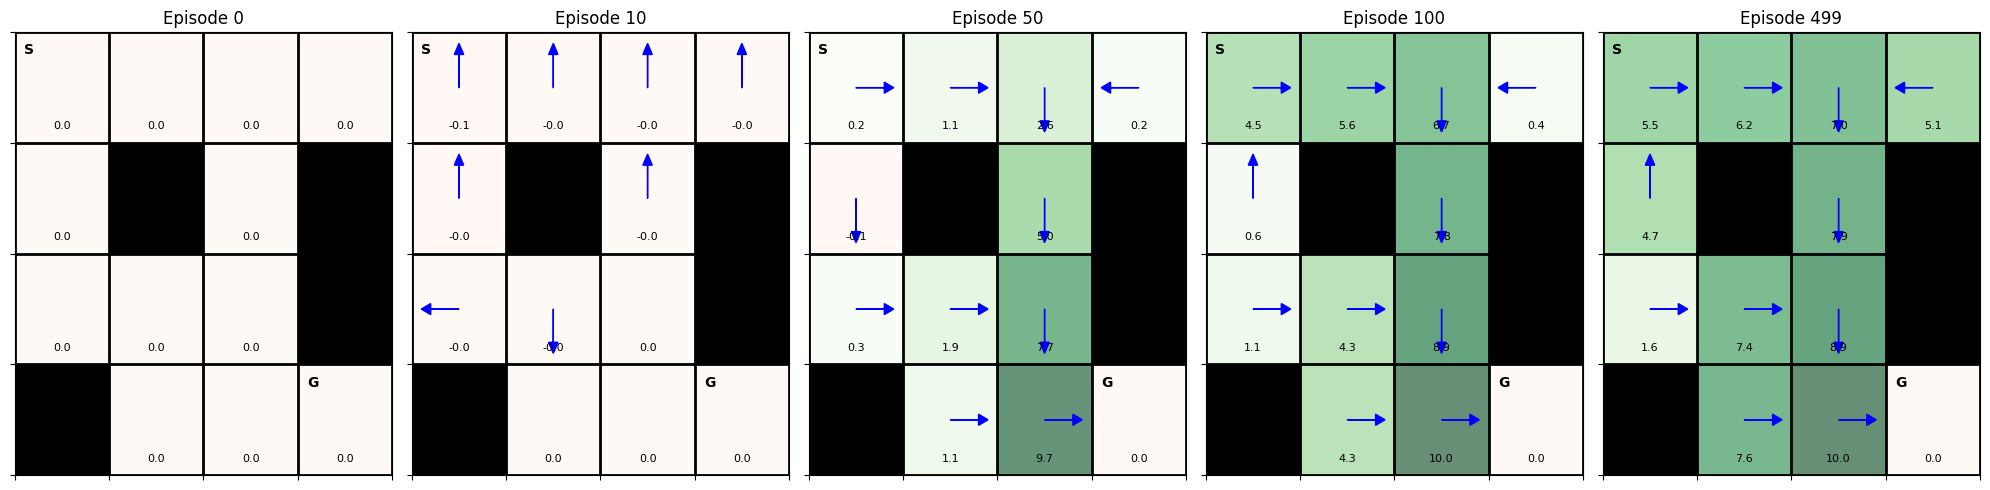

In [ ]:
# ==========================================
# 2. TRAINING & SNAPSHOTS
# ==========================================
def train_and_visualize():
    env = GridWorld()
    # Dimensions: Rows x Cols x Actions
    q_table = np.zeros((4, 4, 4))
    alpha = 0.1    # Learning Rate
    gamma = 0.9    # Discount Factor
    epsilon = 0.2  # Exploration Rate
    episodes = 500

    # We will take snapshots of the Q-table at these episodes
    checkpoints = [0, 10, 50, 100, 499]
    snapshots = []

    for episode in range(episodes):
        state = env.start
        done = False

        # Save snapshot before training episode
        if episode in checkpoints:
            snapshots.append((episode, q_table.copy()))

        while not done:
            r, c = state
            # Epsilon Greedy
            if np.random.rand() < epsilon:
                action = np.random.randint(4)
            else:
                action = np.argmax(q_table[r, c])

            next_state, reward, done = env.step(state, action)
            nr, nc = next_state

            # Q-Update
            old_val = q_table[r, c, action]
            next_max = np.max(q_table[nr, nc])

            # Standard Q-Learning Formula
            new_val = old_val + alpha * (reward + gamma * next_max - old_val)
            q_table[r, c, action] = new_val
            state = next_state

    # ==========================================
    # 3. DRAWING THE GRID (CUSTOM VISUALIZER)
    # ==========================================
    def plot_grid(ax, q_data, title):
        ax.set_title(title)
        ax.set_xlim(0, 4)
        ax.set_ylim(4, 0) # FLIP Y-AXIS: Row 0 is at the Top
        ax.set_xticks(np.arange(0, 5, 1))
        ax.set_yticks(np.arange(0, 5, 1))
        ax.grid(which='both', color='black', linestyle='-', linewidth=2)
        ax.set_xticklabels([])
        ax.set_yticklabels([])

        # Draw Cells
        for r in range(4):
            for c in range(4):
                # 1. Color the cell based on Max Value (V)
                max_val = np.max(q_data[r, c])
                # Normalize color: Goal is +10 (Green), Holes -10 (Red)
                norm_val = max(-10, min(10, max_val))
                if norm_val > 0:
                    color = plt.cm.Greens(norm_val / 10)
                else:
                    color = plt.cm.Reds(abs(norm_val) / 10)

                # Draw Box Background
                rect = patches.Rectangle((c, r), 1, 1, facecolor=color, alpha=0.6)
                ax.add_patch(rect)

                # 2. Draw Special States (S, G, Holes)
                if (r, c) == env.start:
                    ax.text(c+0.1, r+0.2, 'S', weight='bold')
                elif (r, c) == env.goal:
                    ax.text(c+0.1, r+0.2, 'G', weight='bold')
                elif (r, c) in env.obstacles:
                    ax.add_patch(patches.Rectangle((c, r), 1, 1, facecolor='black'))
                    continue # Don't draw arrows in holes

                # 3. Draw Policy Arrow (The best action)
                best_action = np.argmax(q_data[r, c])
                # 0:Up, 1:Right, 2:Down, 3:Left
                dx, dy = 0, 0
                if best_action == 0: dy = -0.3 # Up (Remember Y is flipped)
                if best_action == 1: dx = 0.3  # Right
                if best_action == 2: dy = 0.3  # Down
                if best_action == 3: dx = -0.3 # Left

                # Only draw arrow if value is non-zero (agent has learned something)
                if np.abs(max_val) > 0.01:
                    ax.arrow(c+0.5, r+0.5, dx, dy, head_width=0.1, head_length=0.1, fc='blue', ec='blue')

                # 4. Draw Value Text (The number)
                ax.text(c+0.5, r+0.85, f"{max_val:.1f}", ha='center', va='center', fontsize=8, color='black')

    # Create Subplots
    num_snaps = len(checkpoints)
    fig, axes = plt.subplots(1, num_snaps, figsize=(20, 5))
    for i, (ep, q_data) in enumerate(snapshots):
        plot_grid(axes[i], q_data, f"Episode {ep}")

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    train_and_visualize()

In [2]:
import tensorflow as tf
import h5py as hp
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
